# Lizard Prediction Challenge

## Goal

The goal of this project is to classify images of lizards into the correct species using Deep Learning.

We will follow the Artificial Intelligence course approach:
- Exploratory Data Analysis
- Building a CNN model with TensorFlow/Keras
- Using data augmentation
- Using transfer learning
- Evaluating the model with accuracy, plots and confusion matrix
- Creating a valid Kaggle submission

In [1]:
import os
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import load_img, img_to_array

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## Loading the Data

The CSV files contain the image filenames and labels.  
The training images are stored in class folders inside the `train` directory.

In [45]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

train_df.head()

Train shape: (1334, 2)
Test shape: (326, 1)


,id,label
0,Black_spiny-tailed_iguana_Black_spiny-tailed_i...,0
1,Black_spiny-tailed_iguana_Black_spiny-tailed_i...,0
2,Black_spiny-tailed_iguana_Black_spiny-tailed_i...,0
3,Black_spiny-tailed_iguana_Black_spiny-tailed_i...,0
4,Black_spiny-tailed_iguana_Black_spiny-tailed_i...,0


## Dataset Information

We inspect the structure of the training dataset, data types and possible missing values.

In [46]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1334 entries, 0 to 1333
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   id      1334 non-null   str  
 1   label   1334 non-null   int64
dtypes: int64(1), str(1)
memory usage: 21.0 KB


## Class Distribution

We check whether the dataset is balanced across the 7 lizard classes.
Balanced classes help the model learn fairly.

In [47]:
train_df['label'].value_counts()

label
0    199
5    196
6    196
1    193
2    189
3    183
4    178
Name: count, dtype: int64

In [48]:
from tensorflow.keras.utils import load_img, img_to_array
import matplotlib.pyplot as plt
import os
import math

In [49]:
class_names = sorted(os.listdir("train"))
class_names

['Black_spiny_tailed_iguana',
 'Brown_anole',
 'Cuban_knight_anole',
 'Desert_iguana',
 'Green_anole',
 'Green_iguana',
 'Lesser_Antillean_iguana']

## Image Visualization

We display sample training images to understand image quality, backgrounds, scale differences and dataset complexity.

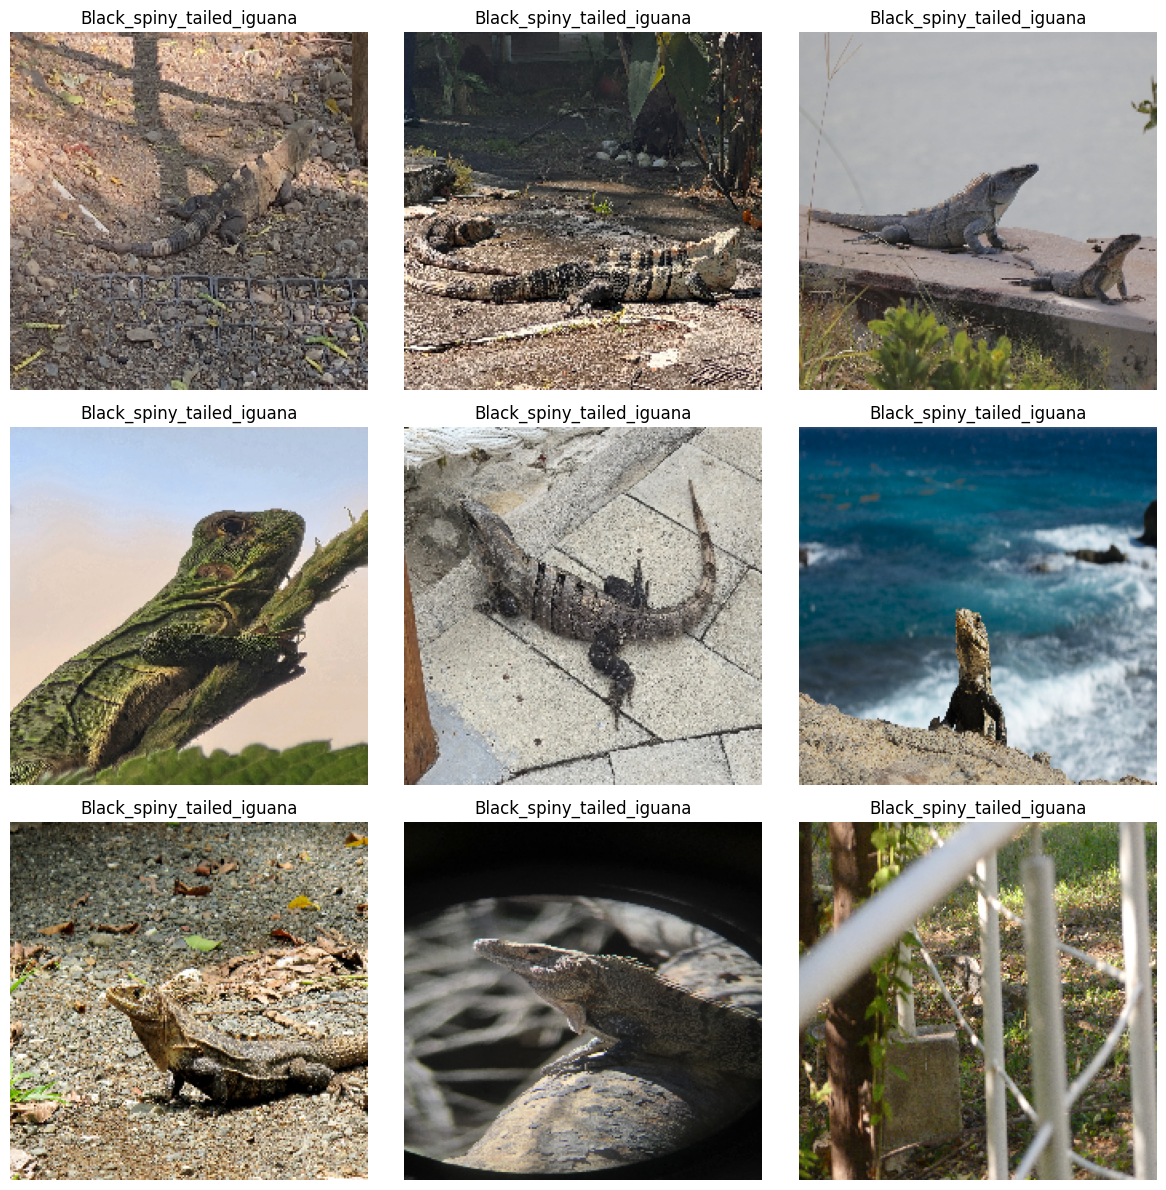

In [50]:
plt.figure(figsize=(12,12))

for i in range(9):

    file_name = train_df.iloc[i]["id"]
    label = train_df.iloc[i]["label"]

    folder_name = class_names[label]

    img_path = os.path.join("train", folder_name, file_name)

    img = load_img(img_path, target_size=(224,224))

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(folder_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [51]:
from sklearn.model_selection import train_test_split

## Train / Validation Split

The dataset is divided into training data and validation data.

- Training set: used to train the model  
- Validation set: used to evaluate model performance on unseen data

Stratified sampling preserves class balance.

In [52]:
train_data, val_data = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df["label"]
)

print("Train samples:", len(train_data))
print("Validation samples:", len(val_data))

Train samples: 1067
Validation samples: 267


## Data Preparation

Images are resized to a fixed size and loaded in batches.

Data augmentation is applied to improve generalization and reduce overfitting.

In [53]:
class_names = sorted(os.listdir("train"))

def create_filepath(df):
    paths = []
    
    for _, row in df.iterrows():
        file_name = row["id"]
        label = row["label"]
        folder = class_names[label]
        full_path = os.path.join("train", folder, file_name)
        paths.append(full_path)
    
    df = df.copy()
    df["filepath"] = paths
    return df

train_data = create_filepath(train_data)
val_data = create_filepath(val_data)

train_data.head()

,id,label,filepath
1132,Green_iguana_Iguana_iguana_3.jpg,5,train\Green_iguana\Green_iguana_Iguana_iguana_...
424,Cuban_knight_anole_Cuban_knight_anole_114.jpg,2,train\Cuban_knight_anole\Cuban_knight_anole_Cu...
4,Black_spiny-tailed_iguana_Black_spiny-tailed_i...,0,train\Black_spiny_tailed_iguana\Black_spiny-ta...
826,Green_anole_Green_anole_172.jpg,4,train\Green_anole\Green_anole_Green_anole_172.jpg
140,Black_spiny-tailed_iguana_Black_spiny-tailed_i...,0,train\Black_spiny_tailed_iguana\Black_spiny-ta...


In [54]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [55]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_gen = ImageDataGenerator(rescale=1./255)

In [56]:
train_loader = train_gen.flow_from_dataframe(
    dataframe=train_data,
    x_col="filepath",
    y_col="label",
    target_size=(224,224),
    batch_size=32,
    class_mode="raw"
)

val_loader = val_gen.flow_from_dataframe(
    dataframe=val_data,
    x_col="filepath",
    y_col="label",
    target_size=(224,224),
    batch_size=32,
    class_mode="raw"
)

Found 1067 validated image filenames.
Found 267 validated image filenames.


# Baseline CNN Model

We first construct a custom Convolutional Neural Network (CNN) as our baseline model.

This model allows us to:
- Establish benchmark performance
- Understand overfitting behavior
- Compare against transfer learning later

In [57]:
from tensorflow.keras import layers, models

baseline_model = models.Sequential([
    
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(7, activation='softmax')   # 7 classes
])

baseline_model.summary()

c:\Users\illad\Desktop\LizardChallenge\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,863 (42.61 MB)

 Trainable params: 11,169,863 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

# Model Compilation

We use:
- Adam optimizer
- Sparse categorical crossentropy
- Accuracy metric

In [58]:
baseline_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model Training

The baseline model is trained on augmented training data while validation data monitors generalization.

We analyze:
- Accuracy
- Validation Accuracy
- Loss
- Validation Loss

Epoch 1/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 1440s 44s/step - accuracy: 0.1687 - loss: 2.1551 - val_accuracy: 0.1798 - val_loss: 1.9213
Epoch 2/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 88s 3s/step - accuracy: 0.2146 - loss: 1.8706 - val_accuracy: 0.2210 - val_loss: 1.8545
Epoch 3/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - accuracy: 0.2512 - loss: 1.8112 - val_accuracy: 0.2921 - val_loss: 1.7716
Epoch 4/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 75s 2s/step - accuracy: 0.2502 - loss: 1.8056 - val_accuracy: 0.2360 - val_loss: 1.8821
Epoch 5/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - accuracy: 0.2849 - loss: 1.7965 - val_accuracy: 0.2322 - val_loss: 1.8413
Epoch 6/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 76s 2s/step - accuracy: 0.2821 - loss: 1.7655 - val_accuracy: 0.2584 - val_loss: 1.8447
Epoch 7/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 74s 2s/step - accuracy: 0.2980 - loss: 1.7527 - val_accuracy: 0.2921 - val_loss: 1.7924
Epoch 8/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 74s 2s/step - accuracy: 0.3027 - loss: 1.7390 - val_accuracy: 0.3258 - val_lo

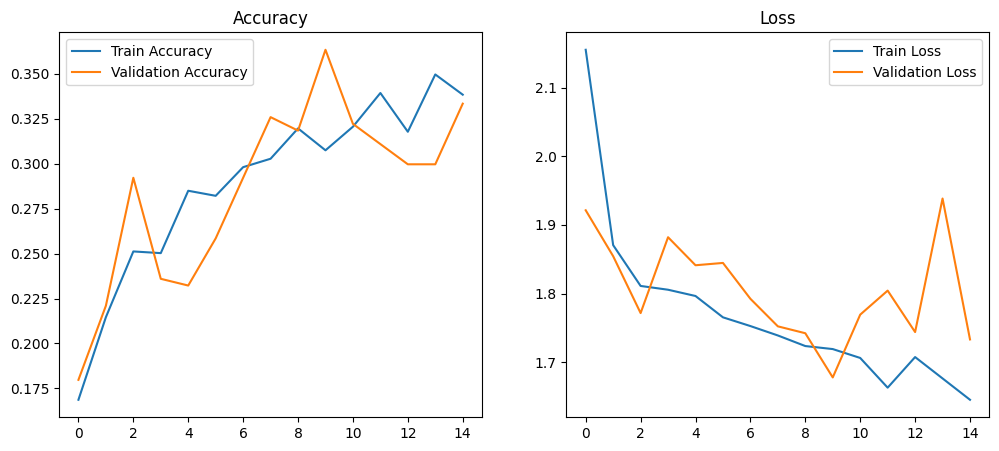

In [59]:
history = baseline_model.fit(
    train_loader,
    validation_data=val_loader,
    epochs=15
)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss")

plt.show()
